<div style="background-color:#f5f3ff; border-radius:8px; padding:12px; text-align:center;">

# **PRACTICA 2: Juego de Tronos · VISUALIZACIÓN DE DATOS**

</div>

*Visualización de Juego de Tronos*

---

**Grupo:** G-7312  
**Número de pareja:** 01  
**Miembros:**  
- Leire Bernárdez Vázquez  
- Carmen Reiné Rueda


---

### **CONFIGURACIONES PREVIAS**

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Importaciones
</div>

In [35]:
import numpy as np
import pandas as pd
import json
import os
import glob
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx       
import geopandas as gpd      
from folium.plugins import MarkerCluster
from collections import Counter, defaultdict

In [36]:
# === CARGA DE LOS DATOS ===

#ruta_data = r"C:\Users\leire\OneDrive\Documents\GitHub\VD_G7312_P02\game_of_thrones\data"
#ruta_map = r"C:\Users\leire\OneDrive\Documents\GitHub\VD_G7312_P02\GOT-Map\GOT-Map"

ruta_data = r"C:\Users\carme\OneDrive - UAM\Documentos\GitHub\VD_G7312_P02\game_of_thrones\data"
ruta_map = r"C:\Users\carme\OneDrive - UAM\Documentos\GitHub\VD_G7312_P02\GOT-Map\GOT-Map"

# --- Carga de archivos JSON principales ---
with open(os.path.join(ruta_data, "characters.json"), "r", encoding="utf-8") as f:
    characters = json.load(f)
with open(os.path.join(ruta_data, "episodes.json"), "r", encoding="utf-8") as f:
    episodes = json.load(f)

with open(os.path.join(ruta_data, "locations.json"), "r", encoding="utf-8") as f:
    locations = json.load(f)

# --- Carga de archivos GeoJSON (mapas) ---
land = gpd.read_file(os.path.join(ruta_map, "land.geojson"))
places = gpd.read_file(os.path.join(ruta_map, "places.geojson"))

---


### **EJERCICIOS**



### <span >**Parte 1: Visualización de grafos con NetworkX**

**En esta primera parte trabajaremos con las relaciones existentes entre los personajes de la serie *Game of Thrones* utilizando la librería** **NetworkX**.  
**El objetivo es construir el grafo de relaciones, obtener métricas y justificar las decisiones de diseño adoptadas (tipo de grafo, relaciones representadas, tamaño y color de nodos, y layout empleado).**


 <div style="background-color:#f5f3ff; color:#6a0dad; padding:15px; border-radius:5px;">
 Apartado 1: Construcción del grafo de relaciones
</div>

**A partir del fichero `characters.json`, construiremos un grafo donde los nodos representen personajes y las aristas indiquen algún tipo de relación entre ellos (parentesco, conflicto, etc.). Las relaciones pueden incluir parentesco (parents, siblings), conflictos (killed, killedBy), entre otras disponibles en el dataset.**


**Limpieza del dataset**

Antes de construir el grafo, realizamos una exploración básica del fichero.


1. Exploración manual de columnas

In [37]:
data_chars = characters["characters"]
print(f"Personajes totales (sin limpieza): {len(data_chars)}")

todos_los_campos = sorted({k for c in data_chars for k in c.keys()})
print("\nTotal de campos en el JSON:", len(todos_los_campos))
print(todos_los_campos)

Personajes totales (sin limpieza): 389

Total de campos en el JSON: 25
['abducted', 'abductedBy', 'actorLink', 'actorName', 'actors', 'allies', 'characterImageFull', 'characterImageThumb', 'characterLink', 'characterName', 'guardedBy', 'guardianOf', 'houseName', 'killed', 'killedBy', 'kingsguard', 'marriedEngaged', 'nickname', 'parentOf', 'parents', 'royal', 'servedBy', 'serves', 'sibling', 'siblings']


2. Después de inspeccionar las columnas, vamos a definir las que realmente representan relaciones.

In [38]:
relaciones_validas = [
    "parents", "parentOf", "siblings", "sibling",
    "killed", "killedBy",
    "marriedEngaged",
    "servedBy", "serves",
    "guardianOf", "guardedBy",
    "allies", "abducted", "abductedBy"
]

3. Filtramos los personajes con al menos una relación. 

In [39]:
def tiene_relaciones(personaje):
    for r in relaciones_validas:
        if r in personaje and personaje[r]:
            return True
    return False

personajes_relacionados = [p for p in data_chars if tiene_relaciones(p)]
print(f"\nPersonajes con al menos una relación: {len(personajes_relacionados)}")


Personajes con al menos una relación: 229


4. Agrupamos duplicados (#1, #2, etc.)

    En el dataset, algunos personajes aparecen repetidos con un sufijo numérico, por ejemplo:
    “Jon Snow”, “Jon Snow #2”, “Jon Snow #3”.

    Estos representan distintas apariciones o versiones del mismo personaje.
    Para unificar toda su información:

    +  Identificamos el nombre base eliminando los sufijos #2, #3, etc.

    * Creamos un grupo único con el nombre "Jon Snow (grupo)" que engloba a todos los duplicados.

    * Reemplazamos en las relaciones (como killedBy, allies, etc.) cualquier referencia a un personaje duplicado por el nombre de su grupo, de forma que las conexiones del grafo no se rompan.


In [40]:
print(f"\nAntes de agrupar. Total de personajes: {len(personajes_relacionados)}")

# Detectar duplicados y agruparlos
def nombre_base(nombre):
    """Elimina sufijos tipo #2, #3 y limpia espacios."""
    return re.sub(r"\s*#\d+$", "", nombre.strip())

# Agrupar por nombre base
grupos = defaultdict(list)
for p in personajes_relacionados:
    base = nombre_base(p["characterName"])
    grupos[base].append(p)

# Fusionar la información de los duplicados
personajes_agrupados = []

for base, miembros in grupos.items():
    if len(miembros) > 1:
        # Crear personaje agrupado (forma plural)
        grupo = {"characterName": f"{base}s"}
        
        # Fusionar relaciones uniendo listas únicas
        for rel in relaciones_validas:
            fusion = []
            for m in miembros:
                if rel in m and isinstance(m[rel], list):
                    fusion.extend(m[rel])
            if fusion:
                grupo[rel] = sorted(list(set(fusion)))
        
        personajes_agrupados.append(grupo)
    else:
        # Si solo hay uno, lo dejamos igual
        personajes_agrupados.append(miembros[0])

print(f"Grupos fusionados creados: {sum(1 for v in grupos.values() if len(v) > 1)}")
print(f"Después de agrupar. Total de personajes únicos: {len(personajes_agrupados)}")

# Crear mapeo original → nombre del grupo
mapa_grupos = {}
for base, miembros in grupos.items():
    nombre_grupo = f"{base}s" if len(miembros) > 1 else base
    for m in miembros:
        mapa_grupos[m["characterName"]] = nombre_grupo

for p in personajes_agrupados:
    for rel in relaciones_validas:
        if rel in p and isinstance(p[rel], list):
            nuevas_rel = []
            for nombre in p[rel]:
                if isinstance(nombre, str):
                    nuevas_rel.append(mapa_grupos.get(nombre, nombre))
            p[rel] = sorted(list(set(nuevas_rel)))



Antes de agrupar. Total de personajes: 229
Grupos fusionados creados: 3
Después de agrupar. Total de personajes únicos: 225


6. Eliminar suicidas sin más relaciones

In [41]:
def es_suicida(personaje):
    if "killedBy" in personaje and personaje["killedBy"]:
        if personaje["characterName"] in personaje["killedBy"]:
            # comprobamos si tiene otras relaciones además del suicidio
            for r in relaciones_validas:
                if r != "killedBy" and personaje.get(r):
                    return False
            return True
    return False

personajes = [p for p in personajes_agrupados if not es_suicida(p)]
print(f"Tras eliminar suicidas: {len(personajes)} personajes")

Tras eliminar suicidas: 225 personajes


7. Exportar JSON limpio

In [42]:
with open("characters_clean.json", "w", encoding="utf-8") as f:
    json.dump(personajes, f, ensure_ascii=False, indent=2)

El archivo limpio se guarda como `characters_clean.json` y servirá como base para el resto de la práctica.


**1. Explora los tipos de relaciones disponibles en el fichero y selecciona al menos tres tipos diferentes para incluir en el grafo.**

El dataset contiene 25 campos distintos. De ellos, hemos seleccionado únicamente aquellos que representan vínculos entre personajes (por ejemplo: parents, parentOf, siblings, killed, killedBy, marriedEngaged, etc.).

Esta selección se ha almacenado en la variable `relaciones_personajes`



**2. Decide qué relaciones deben representarse como dirigidas y cuáles como no 
dirigidas**

In [43]:
# === CARGA DEL JSON LIMPIO ===
ruta_clean = "C:\\Users\\carme\\OneDrive - UAM\\Documentos\\GitHub\\VD_G7312_P02\\characters_clean.json"
with open(ruta_clean, "r", encoding="utf-8") as f:
    personajes = json.load(f)

# === DETECTAMOS RELACIONES PRESENTES Y SU FRECUENCIA ===
rel_counter = Counter()

for c in personajes:
    for k, v in c.items():
        if isinstance(v, list):
            rel_counter[k] += len(v)

# Generar salida en una sola línea
resultado = "Tipos de relaciones encontradas y su frecuencia total: " + \
            ", ".join([f"{rel}: {n}" for rel, n in rel_counter.most_common()])

print(resultado)

Tipos de relaciones encontradas y su frecuencia total: killed: 221, killedBy: 203, siblings: 134, parents: 81, parentOf: 78, marriedEngaged: 55, actors: 31, serves: 22, guardianOf: 15, guardedBy: 12, servedBy: 10, houseName: 10, allies: 8, sibling: 2, abductedBy: 1, abducted: 1


A partir del análisis de frecuencias realizado, observamos que existen relaciones principales que aportan una estructura sólida al grafo, mientras que otras aparecen con muy poca frecuencia y no contribuyen significativamente a la visualización general.

Basándonos en estos resultados y en los ejemplos comentados en clase, hemos decidido centrarnos en **tres tipos de relaciones significativas**:

* **killed** → relación *dirigida*, representa un conflicto donde un personaje mata a otro (A → B).
* **siblings** → relación *no dirigida*, muestra vínculos de hermandad mutua entre personajes.
* **marriedEngaged** → relación *no dirigida*, refleja compromisos o matrimonios. Se ha elegido este tipo frente a otros menos frecuentes porque, con 55 apariciones, aporta variedad al grafo sin sobrecargarlo visualmente.

De este modo, construiremos un **grafo mixto**, ya que combina relaciones **dirigidas** (de conflicto) y **no dirigidas** (de tipo familiar y afectivo), reflejando tanto los enfrentamientos como los lazos personales entre los personajes de *Game of Thrones*.




**3. Crea el grafo en NetworkX, añadiendo atributos a las aristas que indiquen el tipo de 
relación.**

En este apartado construiremos el grafo de relaciones a partir del archivo characters_clean.json.

Cada nodo representa un personaje de *Game of Thrones*, mientras que cada arista indica una relación entre dos personajes, pudiendo ser de conflicto (killed), hermandad (siblings) o vínculo afectivo (marriedEngaged).

Además, a cada arista se le asignará un atributo que identifica el tipo de relación, lo que permitirá diferenciar visualmente las conexiones en el grafo mediante colores y estilos de línea.

In [44]:
# === CREAR GRAFO MIXTO ===
G = nx.MultiDiGraph()  # permite direccionalidad mixta

# === AÑADIR NODOS ===
for p in personajes:
    nombre = p.get("characterName")
    if not nombre:
        continue  # seguridad: saltar si no hay nombre
    G.add_node(
        nombre,
        house=p.get("houseName"),
        royal=p.get("royal"),
        kingsguard=p.get("kingsguard"),
        nickname=p.get("nickname") # añadimos todos los atributos por si deseamos usarlos luego
    )
    
# === AÑADIR RELACIONES DIRIGIDAS (killed) ===
for p in personajes:
    origen = p.get("characterName")
    if not origen:
        continue

    if "killed" in p:
        for destino in p["killed"]:
            if not destino or destino == origen:
                continue
            G.add_edge(origen, destino, relation="killed", directed=True)

# === AÑADIR RELACIONES NO DIRIGIDAS (siblings, marriedEngaged) ===
for p in personajes:
    origen = p.get("characterName")
    if not origen:
        continue

    for tipo in ["siblings", "marriedEngaged"]:
        if tipo not in p:
            continue
        for destino in p[tipo]:
            if not destino or destino == origen:
                continue
            # Añadimos ambas direcciones para simular relación no dirigida
            G.add_edge(origen, destino, relation=tipo, directed=False)
            G.add_edge(destino, origen, relation=tipo, directed=False)

# === RESUMEN ===
print(f"Nodos totales: {G.number_of_nodes()}")
print(f"Aristas totales: {G.number_of_edges()}")

# Contamos tipos de relaciones
tipos_rel = [d["relation"] for _, _, d in G.edges(data=True)]
for rel, n in Counter(tipos_rel).items():
    print(f"- {rel}: {n}")


Nodos totales: 279
Aristas totales: 595
- siblings: 268
- killed: 217
- marriedEngaged: 110


In [45]:
# Todos los nombres originales
nombres_originales = {p["characterName"] for p in personajes}

# Nodos añadidos automáticamente
nodos_extra = [n for n in G.nodes if n not in nombres_originales]

print(f"Nodos totales en el grafo: {G.number_of_nodes()}")
print(f"Personajes originales: {len(nombres_originales)}")
print(f"Nodos adicionales detectados: {len(nodos_extra)}")

if nodos_extra:
    print("Nombres de nodos adicionales:", nodos_extra[:])


Nodos totales en el grafo: 279
Personajes originales: 225
Nodos adicionales detectados: 54
Nombres de nodos adicionales: ['Frey Soldier #1', 'Ghita', 'Bolton Officer', 'Soldier Tom', 'Iggo', 'Oznak zo Pahl', 'Eleanor', "Eleanor's Daughter", 'Khal Brozho', 'Khal Forzho', 'Khal Qorro', 'Zalla', 'Kevin Eldon', 'Laurence Spellman', 'Faith Militant', "King's Landing Boaster", 'Rennick', 'Belicho Paenymion', 'Torrhen Karstark', 'Barra', 'Despondent Man', 'Meereenese Champion', 'Norvoshi Pit Fighter', 'Cooper', 'Donnel Hill', 'Axell Florent', 'Son of the Harpy', 'Bolton Soldier', 'Lady Cerwyn', 'Master Torturer', 'Medger Cerwyn', 'Old Woman', 'Unidentified Cerwyn', 'Great Master', 'Dying Man', 'Frey Soldier #2', 'Kings Landing Rioter #1', 'Kings Landing Rioter #2', 'Kings Landing Rioter #3', 'Lowell', 'Morgan', 'Riddell', 'Steve', 'Gordy', 'Simpson', "Olly's Mother", 'Tortured Prisoner', 'Harrag', 'Maester Caleotte', 'Guymon', "Mole's Town Whore", 'Old Man', 'Hoster Tully', 'Catelyn Tully']


Los “nodos adicionales” son personajes secundarios, extras o sin ficha propia en el JSON, pero que forman parte de las relaciones de otros.

**4. Realiza una primera visualización del grafo completo, diferenciando visualmente 
los tipos de relaciones mediante colores o estilos de línea.**

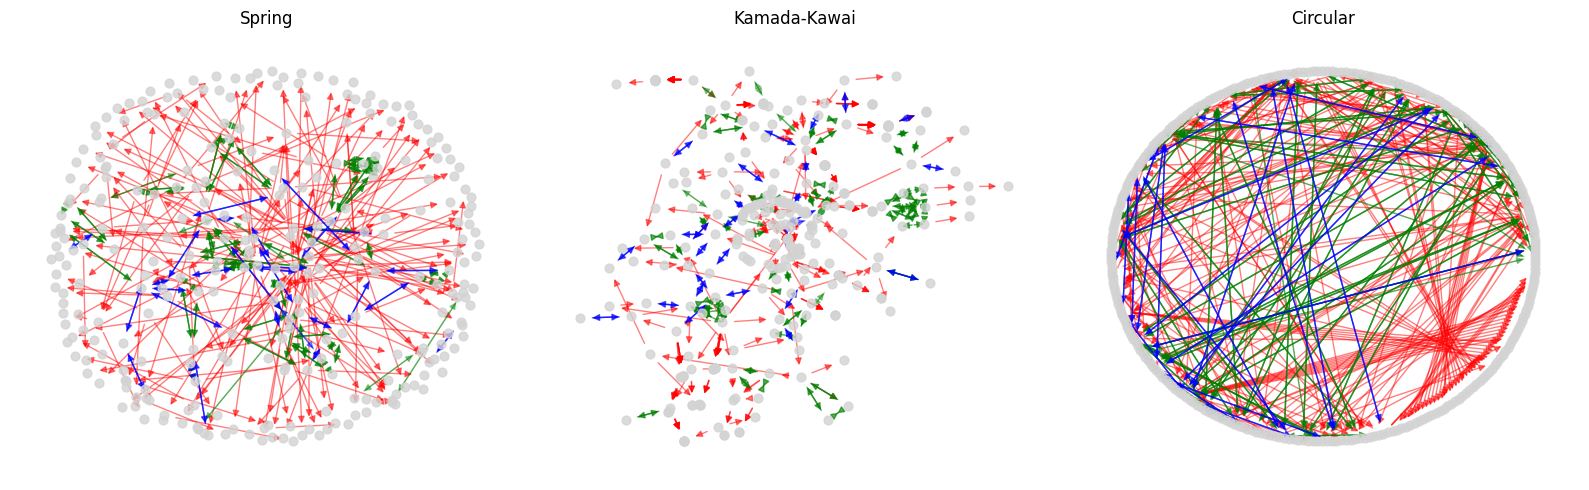

In [46]:
# === COMPARACIÓN DE LAYOUTS ===
layouts = {
    "Spring": nx.spring_layout(G, k=0.4, seed=42),
    "Kamada-Kawai": nx.kamada_kawai_layout(G),
    "Circular": nx.circular_layout(G)
}
# Creamos listas de aristas separadas por tipo para dibujarlas con distinto color
edges_killed = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "killed"]
edges_siblings = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "siblings"]
edges_married = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "marriedEngaged"]

plt.figure(figsize=(16, 5))
for i, (name, pos_i) in enumerate(layouts.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(name, fontsize=12)
    nx.draw_networkx_nodes(G, pos_i, node_size=40, node_color="lightgray", alpha=0.8)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_killed, edge_color="red", alpha=0.5)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_siblings, edge_color="green", alpha=0.4)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_married, edge_color="blue", alpha=0.4)
    plt.axis("off")
plt.tight_layout()
plt.show()


En esta celda se comparan tres layouts disponibles en NetworkX para visualizar el grafo:
- **Spring:** reparte los personajes de manera equilibrada, agrupando mejor los que están más conectados.

- **Kamada-Kawai:** ofrece una disposición algo más separada, pero menos uniforme.

- **Circular:** sitúa todos los nodos en un círculo, lo que hace más difícil distinguir las conexiones.

Después de probarlos, el **Spring layout** es el que mejor muestra la red de forma clara y comprensible, ya que permite ver los grupos de personajes y sus relaciones sin tanto solapamiento visual.

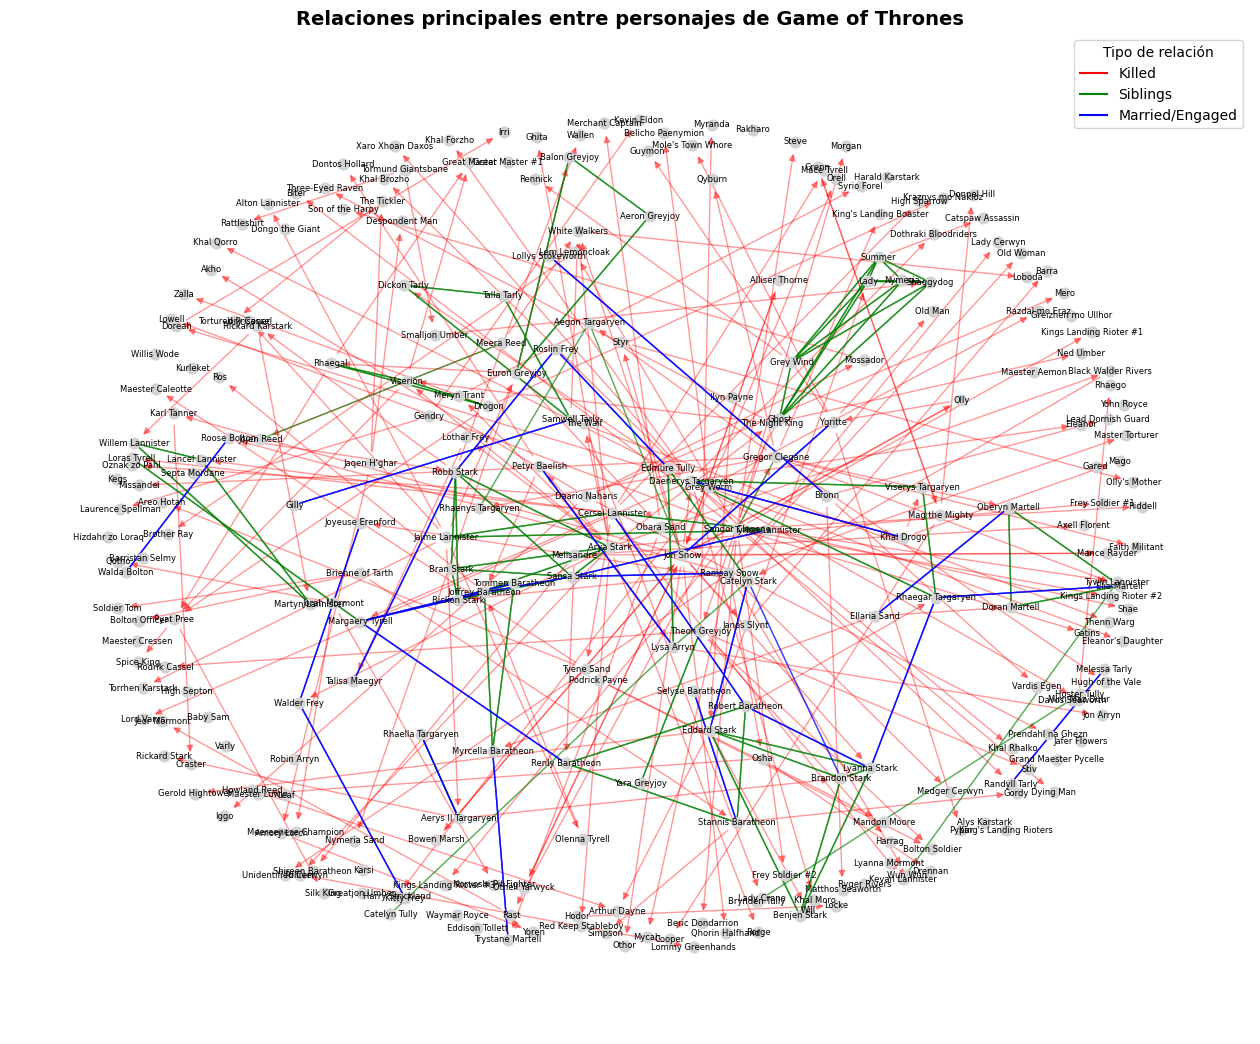

In [47]:
# Layout seleccionado: SPRING
from matplotlib.pyplot import hlines


pos = nx.spring_layout(G, k=0.5, seed=42) 

# === VISUALIZACIÓN INICIAL DEL GRAFO ===
plt.figure(figsize=(16, 13))
plt.title("Relaciones principales entre personajes de Game of Thrones", fontsize=14, fontweight='bold')

# Dibujamos nodos 
nx.draw_networkx_nodes(G, pos, node_size=60, node_color="lightgray")

# Dibujamos aristas por tipo de relación
nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.4, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=edges_married, edge_color="blue", alpha=0.5, arrows=False)

# Añadimos algunos nombres de personajes (uno de cada 35 nodos)
nx.draw_networkx_labels(G, pos, font_size=6, font_color="black")

legend_handles = [
    plt.Line2D([], [], color='red', label='Killed'),
    plt.Line2D([], [], color='green', label='Siblings'),
    plt.Line2D([], [], color='blue', label='Married/Engaged')
]
plt.legend(handles=legend_handles, title="Tipo de relación", loc="upper right")

plt.axis("off") #Ocultamos ejes     
plt.show()



En este primer gráfico se representa el conjunto completo de personajes y relaciones seleccionadas

Cada tipo de relación se ha diferenciado visualmente por color:
- **Killed** → relaciones de conflicto (dirigidas)
- **Siblings** → lazos de hermandad (no dirigidas)
- **Married/Engaged** → vínculos afectivos o matrimoniales  (no dirigidas)

Se ha empleado el layout **spring_layout**, que equilibra la distancia entre nodos para facilitar la lectura de la red.  
El parámetro *k* ajusta la separación media entre nodos y *seed=42* garantiza estabilidad visual en cada ejecución.

Los nodos, representados en gris claro y con tamaño uniforme, permiten centrar la atención en las aristas, que se diferencian con colores primarios fácilmente reconocibles.
Las relaciones de tipo killed incluyen flechas para indicar dirección, mientras que las familiares y afectivas se muestran sin ellas por ser recíprocas.

Se han incluido etiquetas pequeñas solo para algunos personajes, evitando saturar el grafo, y se han ocultado los ejes para lograr una visualización más limpia.
Esta primera vista ofrece una visión general de la red antes de aplicar criterios más detallados.

**5. Ajusta el tamaño de los nodos en función del número total de relaciones de cada personaje (grado).**

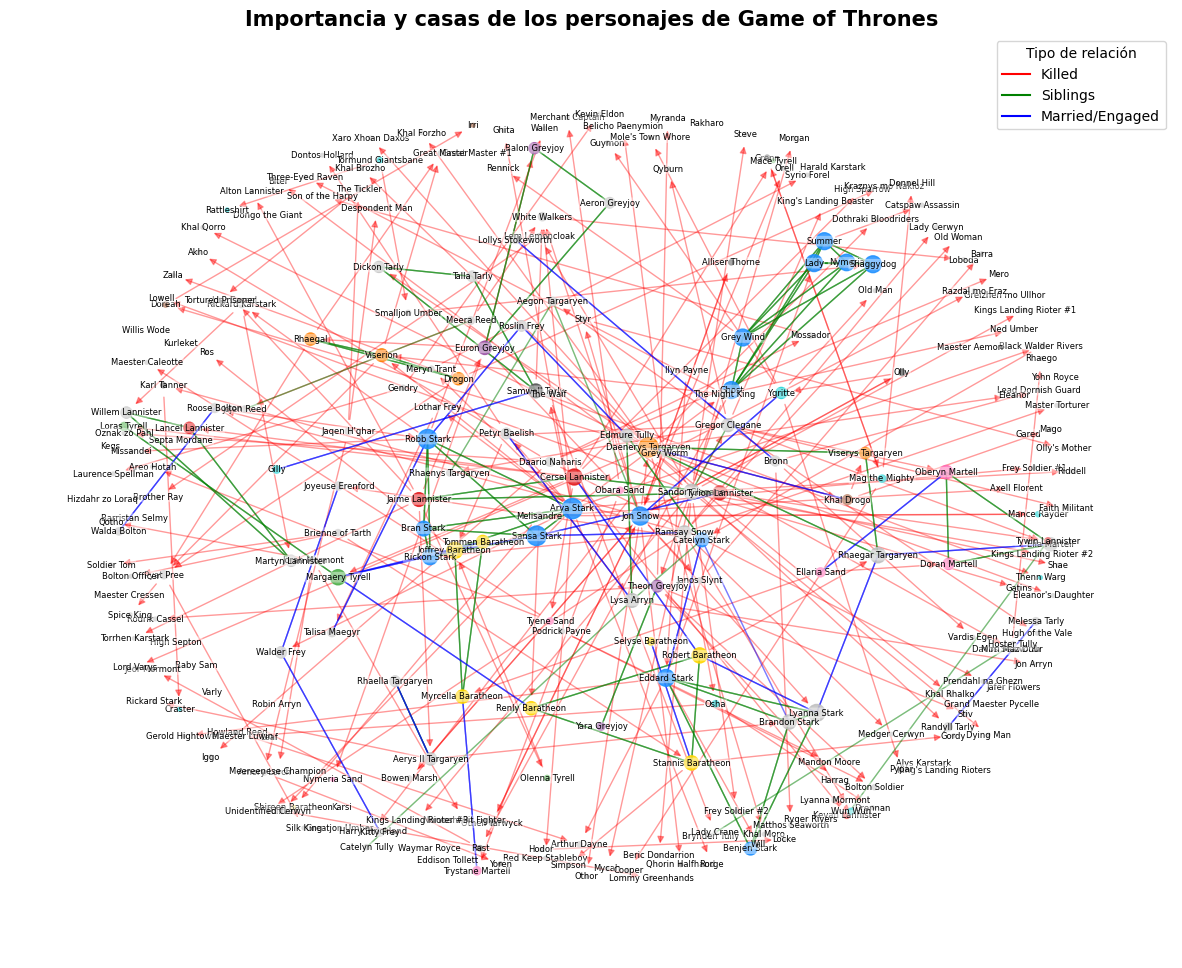

In [48]:
grados = dict(G.degree())
node_sizes = [grados[n] * 7 for n in G.nodes()]

with open(os.path.join(ruta_data, "characters-groups.json"), "r", encoding="utf-8") as f:
    grupos_data = json.load(f)["groups"]

colores = {
    "Stark": "#1E90FF", "Lannister": "#E41A1C", "Targaryen": "#FF7F00",
    "Baratheon": "#FFD700", "Tyrell": "#4DAF4A", "Greyjoy": "#984EA3",
    "Martell": "#FF69B4", "Night's Watch": "#555555", "Dothraki": "#A0522D",
    "Wildlings": "#00CED1", "Otros": "#C0C0C0"
}
color_por_personaje = {p: colores.get(g["name"], colores["Otros"])
                       for g in grupos_data for p in g["characters"]}
node_colors = [color_por_personaje.get(n, colores["Otros"]) for n in G.nodes()]

plt.figure(figsize=(15, 12))
plt.title("Importancia y casas de los personajes de Game of Thrones", fontsize=15, fontweight="bold")

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.85
)

nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.3, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=edges_married, edge_color="blue", alpha=0.3, arrows=False)

nx.draw_networkx_labels(
    G, pos,
    font_size=6,
    font_color="black",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none", boxstyle="round,pad=0.1")
)
plt.legend(handles=legend_handles, title="Tipo de relación", loc="upper right")

plt.axis("off")
plt.show()


En este apartado se ha ajustado el **tamaño de los nodos** en función del **grado de cada personaje**, es decir, del número total de relaciones que mantiene dentro del grafo.

De este modo:
- Los personajes con **más conexiones** (ya sea por parentesco, hermandad o conflictos) aparecen con un tamaño mayor.
- Los personajes secundarios, con pocas o ninguna relación, se muestran con nodos más pequeños y periféricos.

Además, se ha añadido un esquema de **colores por casa o grupo** a partir del archivo `characters-groups.json`, 
lo que permite identificar visualmente las alianzas y vínculos familiares más relevantes:

| Color | Casa o grupo |
|:------|:--------------|
| 🔴 Rojo | Lannister |
| 🟠 Naranja | Targaryen |
| 🟡 Amarillo | Baratheon |
| 🟢 Verde | Tyrell |
| 🔵 Azul | Stark |
| ⚫ Gris oscuro | Night’s Watch |
| 🟤 Marrón | Dothraki |
| 🟣 Morado | Greyjoy |
| 🟢 Verde lima | Martell |
| ⚪ Gris claro | Otros / secundarios |

El resultado permite observar cómo las **casas más influyentes** (Stark, Lannister, Targaryen) concentran los nodos más grandes y las mayores interconexiones.  
En cambio, los personajes menores o aislados aparecen dispersos en los bordes del grafo, evidenciando su menor relevancia dentro de la red.

En esta versión final del grafo se ha mejorado la legibilidad visual:
- Se ha utilizado una paleta de colores con mayor contraste, adaptada para distinguir las principales casas.
- Los nodos sin grupo se muestran en **gris claro con borde negro**, evitando que desaparezcan en el fondo.
- Se ha añadido un fondo blanco translúcido a las etiquetas para facilitar su lectura sobre nodos de color intenso.


**Después de realizar el gráfico, responde brevemente:** 

**• ¿Qué tipo de grafo has decidido utilizar (dirigido, no dirigido o mixto)? ¿Por qué?**** 

Hemos utilizado un grafo mixto, ya que algunas relaciones son dirigidas (por ejemplo, killed, donde existe un emisor y un receptor) y otras no dirigidas (como siblings o parents, que representan vínculos mutuos). Este enfoque permite reflejar con mayor fidelidad la naturaleza de las interacciones entre los personajes.

**• ¿Qué criterio has seguido para definir el tamaño y color de los nodos?**

El tamaño de cada nodo se ha definido en función de su grado, es decir, del número total de relaciones que mantiene cada personaje. De este modo, los personajes con más conexiones destacan visualmente.
El color de los nodos representa la casa o grupo al que pertenece cada personaje (por ejemplo, Stark, Lannister, Targaryen…), permitiendo identificar visualmente alianzas familiares o de pertenencia.

**• ¿Qué layout te ha resultado más adecuado para representar las relaciones?** 

Tras comparar varias distribuciones (spring_layout, kamada_kawai_layout y circular_layout), el layout Spring resultó el más equilibrado, ya que organiza los nodos de forma natural según sus conexiones, agrupando los personajes más relacionados en el centro y dejando los menos conectados en la periferia. Esto facilita la lectura y comprensión global de la red.

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 2: Análisis de centralidad y relevancia de personajes 
</div>

**Una vez construido el grafo, calcula diferentes medidas de centralidad para identificar los personajes más relevantes dentro de la red.** 


**1. Aplica diferentes métricas de centralidad de la librería NetworkX a cada nodo del grafo con las relaciones que has seleccionado en el apartado anterior.** 

**2. Haz una visualización por cada métrica donde se muestre los 10 personajes más importantes según cada una de ellas. Aquí se debe observar al menos el nombre del personaje y el valor de la métrica.** 

Las tres métricas coinciden en destacar a Eddard Stark, Jon Snow, Daenerys Targaryen y Arya Stark como los personajes más relevantes del grafo, ya sea por número de vínculos, posición estructural o cercanía global.
En conjunto, esto evidencia que la red de Game of Thrones gira en torno a las casas Stark y Targaryen, con conexiones clave hacia los Lannister y Baratheon.
Los valores también reflejan coherentemente la narrativa de la serie, donde estos personajes funcionan como ejes de poder, unión o conflicto

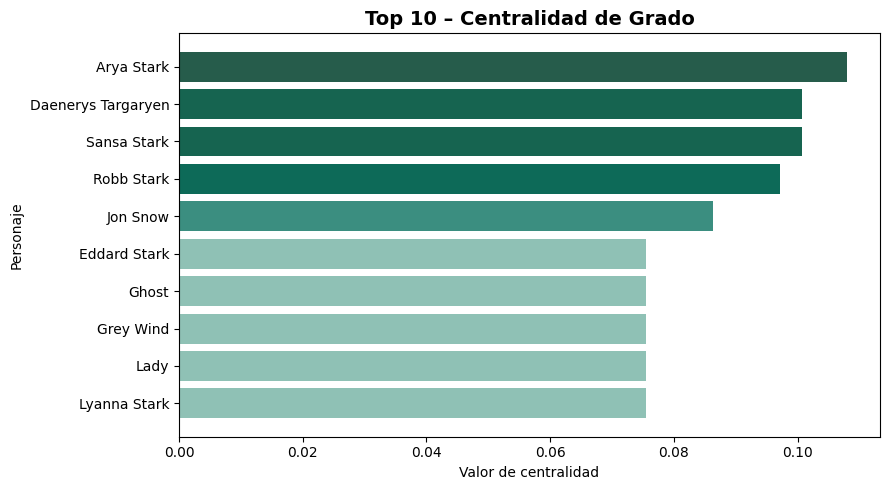

,Personaje,Valor de centralidad
0,Arya Stark,0.107914
1,Daenerys Targaryen,0.100719
2,Sansa Stark,0.100719
3,Robb Stark,0.097122
4,Jon Snow,0.086331
5,Eddard Stark,0.075540
6,Ghost,0.075540
7,Grey Wind,0.075540
8,Lady,0.075540
9,Lyanna Stark,0.075540


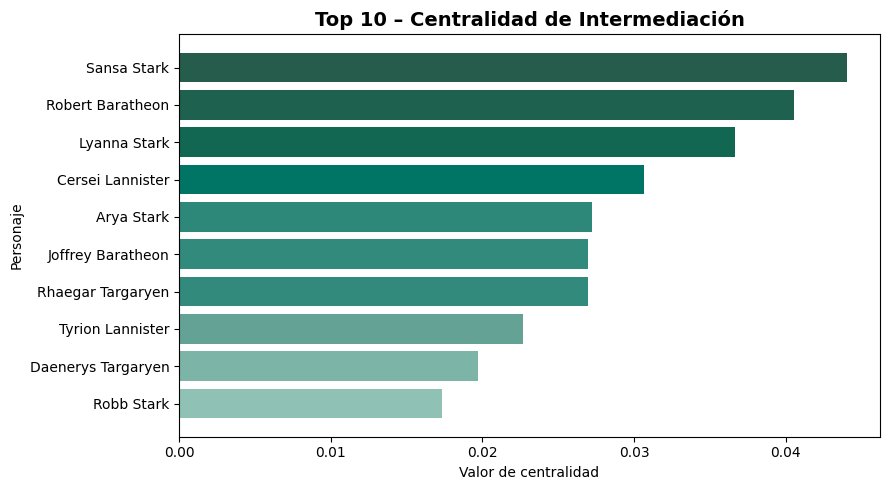

,Personaje,Valor de centralidad
0,Sansa Stark,0.044023
1,Robert Baratheon,0.040546
2,Lyanna Stark,0.036648
3,Cersei Lannister,0.030680
4,Arya Stark,0.027237
5,Joffrey Baratheon,0.026979
6,Rhaegar Targaryen,0.026977
7,Tyrion Lannister,0.022702
8,Daenerys Targaryen,0.019699
9,Robb Stark,0.017331


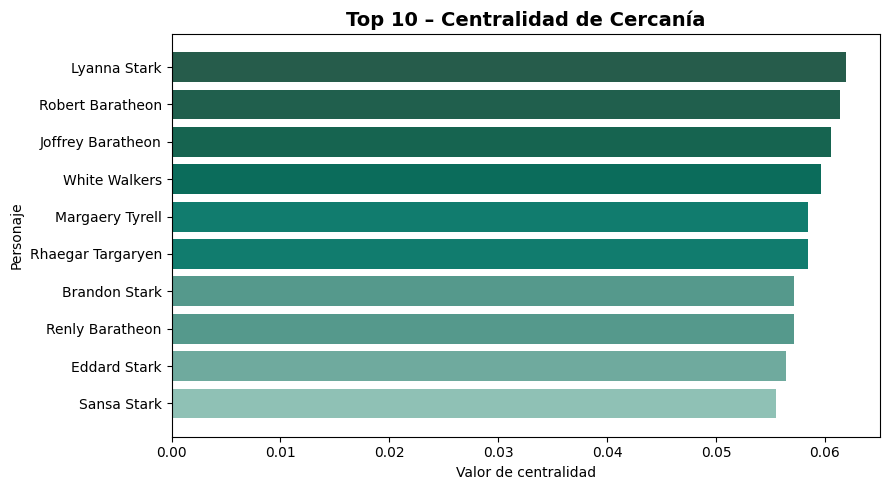

,Personaje,Valor de centralidad
0,Lyanna Stark,0.061967
1,Robert Baratheon,0.061399
2,Joffrey Baratheon,0.060565
3,White Walkers,0.059617
4,Margaery Tyrell,0.058449
5,Rhaegar Targaryen,0.058449
6,Brandon Stark,0.057200
7,Renly Baratheon,0.057200
8,Eddard Stark,0.056476
9,Sansa Stark,0.055539


In [58]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# === CÁLCULO DE DIFERENTES MÉTRICAS DE CENTRALIDAD ===
centralidad_grado = nx.degree_centrality(G)
centralidad_betweenness = nx.betweenness_centrality(G)
centralidad_closeness = nx.closeness_centrality(G)


# --- Paleta personalizada de verde oscuro a verde claro ---
colores_paleta = ["#265C4B", "#146551", "#007566", "#589A8D", "#8FC1B5"]
verde_gradiente = LinearSegmentedColormap.from_list("verde_gradiente", colores_paleta[::-1])

# --- Función para graficar el top 10 ---
def graficar_top10(metrica, titulo):
    top10 = sorted(metrica.items(), key=lambda x: x[1], reverse=True)[:10]
    nombres = [n for n, _ in top10]
    valores = [v for _, v in top10]

    # Normalizamos los valores para mapearlos al gradiente
    norm_vals = (valores - np.min(valores)) / (np.max(valores) - np.min(valores))
    colores = [verde_gradiente(v) for v in norm_vals]

    plt.figure(figsize=(9, 5))
    plt.title(titulo, fontsize=14, fontweight="bold")
    plt.barh(nombres[::-1], valores[::-1], color=colores[::-1])
    plt.xlabel("Valor de centralidad")
    plt.ylabel("Personaje")
    plt.tight_layout()
    plt.show()

    # Mostrar tabla con valores
    df = pd.DataFrame({"Personaje": nombres, "Valor de centralidad": valores})
    display(df)

# --- Visualización de las tres métricas con tu paleta ---
graficar_top10(centralidad_grado, "Top 10 – Centralidad de Grado")
graficar_top10(centralidad_betweenness, "Top 10 – Centralidad de Intermediación")
graficar_top10(centralidad_closeness, "Top 10 – Centralidad de Cercanía")


En lugar de emplear paletas multicolor, se ha optado por un color único con variaciones de intensidad, de modo que el tono más oscuro representa el valor de centralidad más alto.

Este enfoque facilita la lectura y mantiene una correspondencia visual intuitiva entre importancia e intensidad, evitando interpretaciones erróneas derivadas de cambios de tono.

**3. Realiza una nueva visualización en la que el tamaño del nodo represente la importancia del personaje según la métrica que consideras que muestra mejor los personajes más importantes de la historia.** 

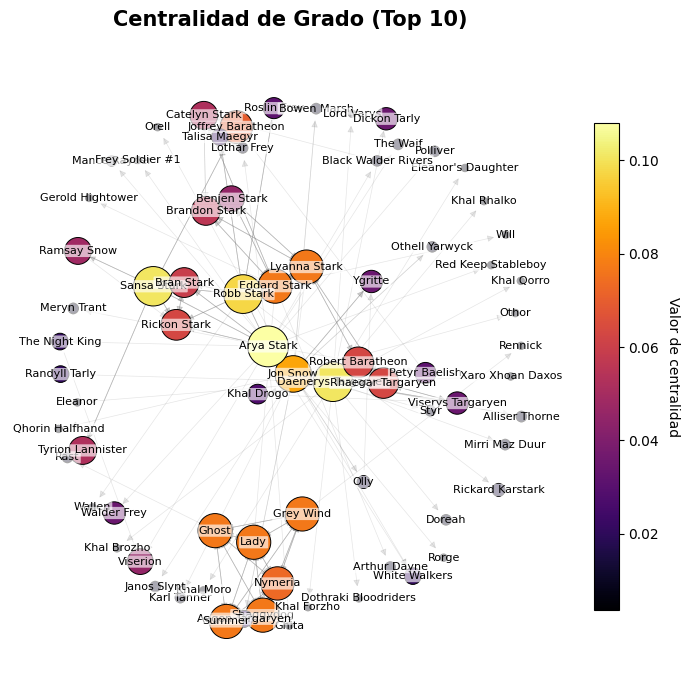

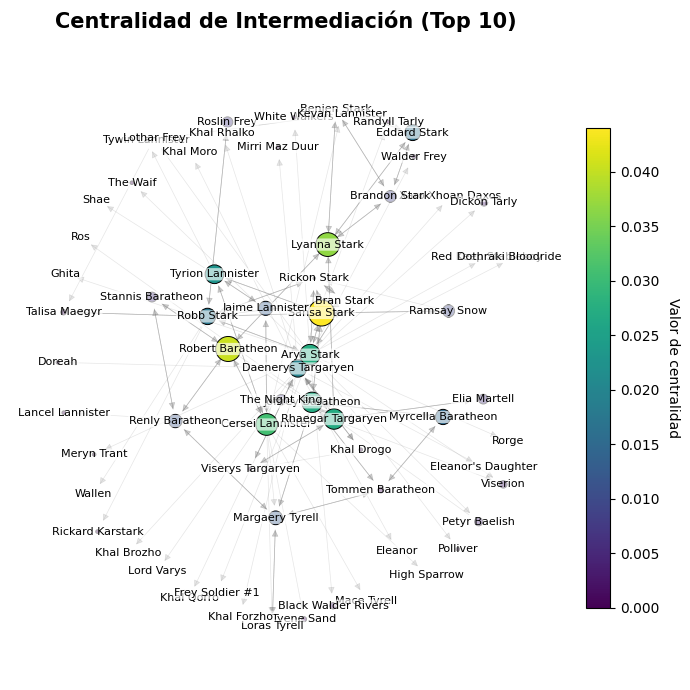

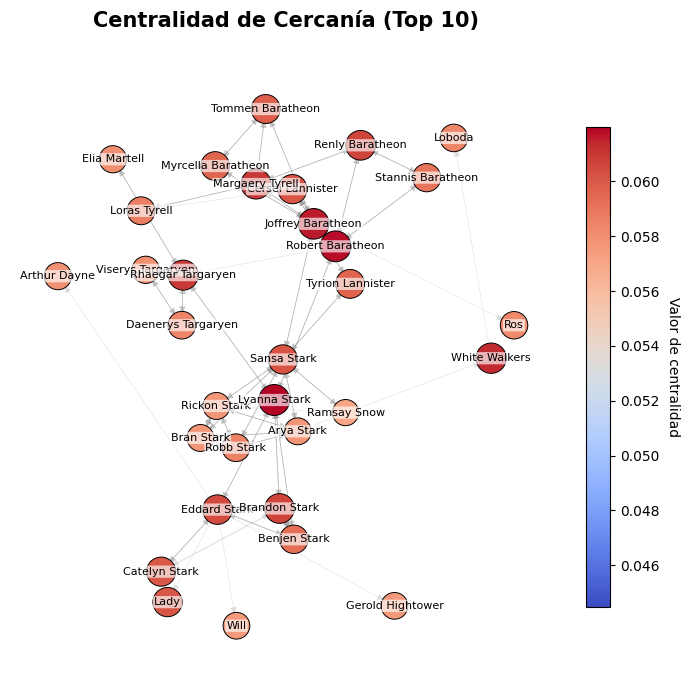

In [59]:
import warnings
warnings.filterwarnings("ignore")

# === VISUALIZACIÓN DE CENTRALIDAD CON MAPA DE CALOR (TOP 10) ===

def visualizar_centralidad(G, centralidad, titulo, cmap):
    # Ordenamos y seleccionamos top 10
    top10 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
    top_nodes = [n for n, _ in top10]

    # Subgrafo con los 10 principales + vecinos
    nodos_relacionados = set(top_nodes)
    for n in top_nodes:
        nodos_relacionados.update(G.neighbors(n))
    subG = G.subgraph(nodos_relacionados)

    # Layout con más separación
    pos_sub = nx.spring_layout(subG, k=0.8, seed=42)

    # Normalización de valores
    valores_nodos = [centralidad.get(n, 0) for n in subG.nodes()]
    max_val = max(valores_nodos) if max(valores_nodos) > 0 else 1
    colores = plt.cm.get_cmap(cmap)([v / max_val for v in valores_nodos])
    tamaños = [8000 * v for v in valores_nodos]

    # --- Crear figura ---
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(titulo, fontsize=15, fontweight="bold", pad=20)

    # Dibujar aristas
    nx.draw_networkx_edges(subG, pos_sub, alpha=0.2, edge_color="gray", arrows=True, width=0.5, ax=ax)

    # Dibujar nodos (más visibles)
    nx.draw_networkx_nodes(
        subG, pos_sub,
        node_color=colores,
        node_size=tamaños,
        edgecolors="black",  # bordes negros para mejor contraste
        linewidths=0.7,
        ax=ax
    )

    # Etiquetas: más grandes y con fondo blanco translúcido
    nx.draw_networkx_labels(
        subG, pos_sub,
        font_size=8,
        font_color="black",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", boxstyle="round,pad=0.1"),
        ax=ax
    )

    # Barra de color (más grande y mejor colocada)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(valores_nodos), vmax=max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
    cbar.set_label("Valor de centralidad", rotation=270, labelpad=15, fontsize=10)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- Aplicar a cada métrica ---
visualizar_centralidad(G, centralidad_grado, "Centralidad de Grado (Top 10)", "inferno")
visualizar_centralidad(G, centralidad_betweenness, "Centralidad de Intermediación (Top 10)", "viridis")
visualizar_centralidad(G, centralidad_closeness, "Centralidad de Cercanía (Top 10)", "coolwarm")




Usar colores mas significativos

**Después de realizar el gráfico, responde brevemente:**



**• ¿Qué diferencias observas entre las distintas medidas de centralidad?** 



**• ¿Los personajes más “centrales” coinciden con los más importantes en la historia?** 



**• ¿Cómo influye la forma de calcular la centralidad en la interpretación del grafo?** 

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 3: Subredes y comunidades  
</div>

**En este apartado se explorará la estructura interna de la red mediante el análisis de subgrupos de personajes.** 

**1. Crea subgrafos a partir de uno o varios tipos de relación (por ejemplo, solo relaciones familiares o solo relaciones de conflicto).** 

Número de nodos en el subgrafo familiar: 82
Número de aristas en el subgrafo familiar: 98


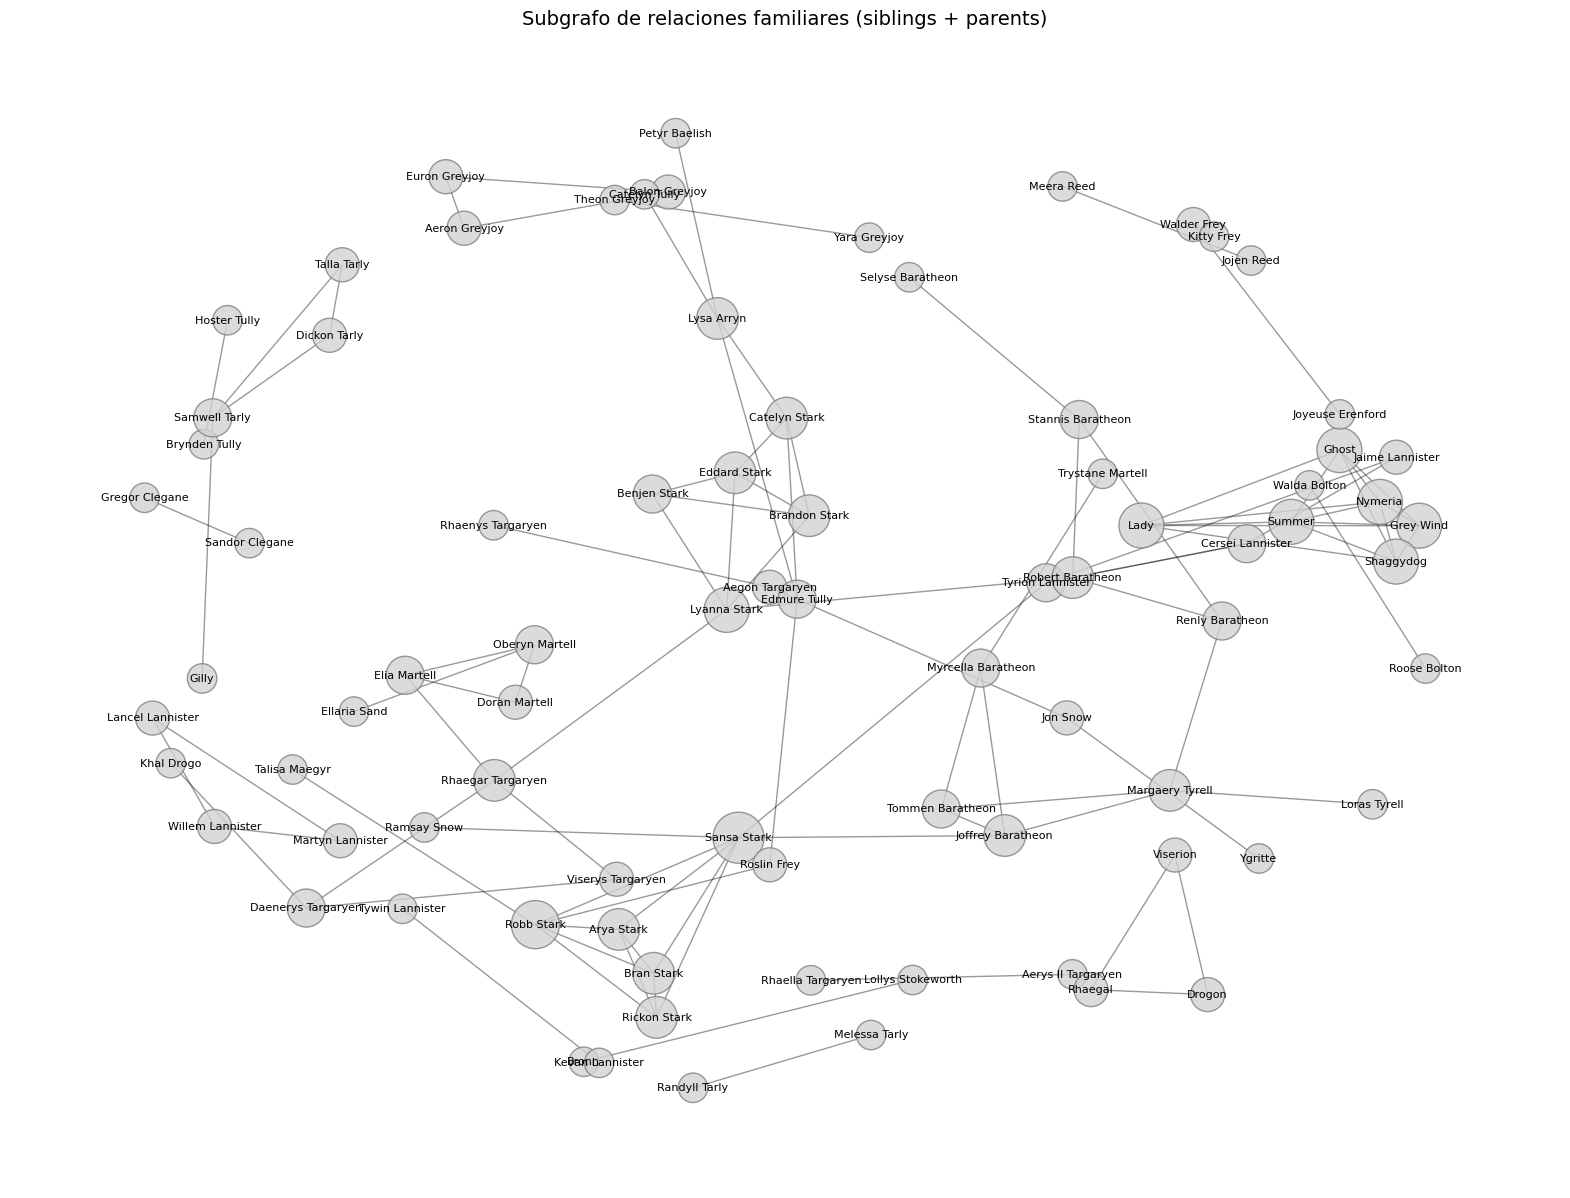

In [123]:
# Subgrafo de relaciones familiares (siblings y parents)
relaciones_familia = {"siblings", "parents", "sibling", "parentOf", "marriedEngaged"}

# Creamos el subgrafo filtrando las aristas del grafo original
edges_familia = [(u, v, d) for u, v, d in G.edges(data=True) if d['relation'] in relaciones_familia]
G_familia = nx.Graph()  # grafo no dirigido para relaciones familiares
G_familia.add_edges_from(edges_familia)

print(f"Número de nodos en el subgrafo familiar: {G_familia.number_of_nodes()}")
print(f"Número de aristas en el subgrafo familiar: {G_familia.number_of_edges()}")

# --- VISUALIZACIÓN DEL SUBGRAFO ---
plt.figure(figsize=(20, 15))
pos_familia = nx.spring_layout(G_familia, scale= 500, k=0.5, seed=42, gravity=0.1)

# Tamaño de nodos proporcional a su grado (más conexiones = más grande)
node_sizes = [300 + 150 * G_familia.degree(n) for n in G_familia.nodes()]

nx.draw_networkx_nodes(G_familia, pos_familia, node_size=node_sizes, node_color="lightgrey", alpha=0.8, edgecolors="gray")
nx.draw_networkx_edges(G_familia, pos_familia, alpha=0.4)
nx.draw_networkx_labels(G_familia, pos_familia, font_size=8)

plt.title("Subgrafo de relaciones familiares (siblings + parents)", fontsize=14)
plt.axis("off")
plt.show()


Número de nodos en el subgrafo de conflicto: 229
Número de aristas en el subgrafo de conflicto: 211


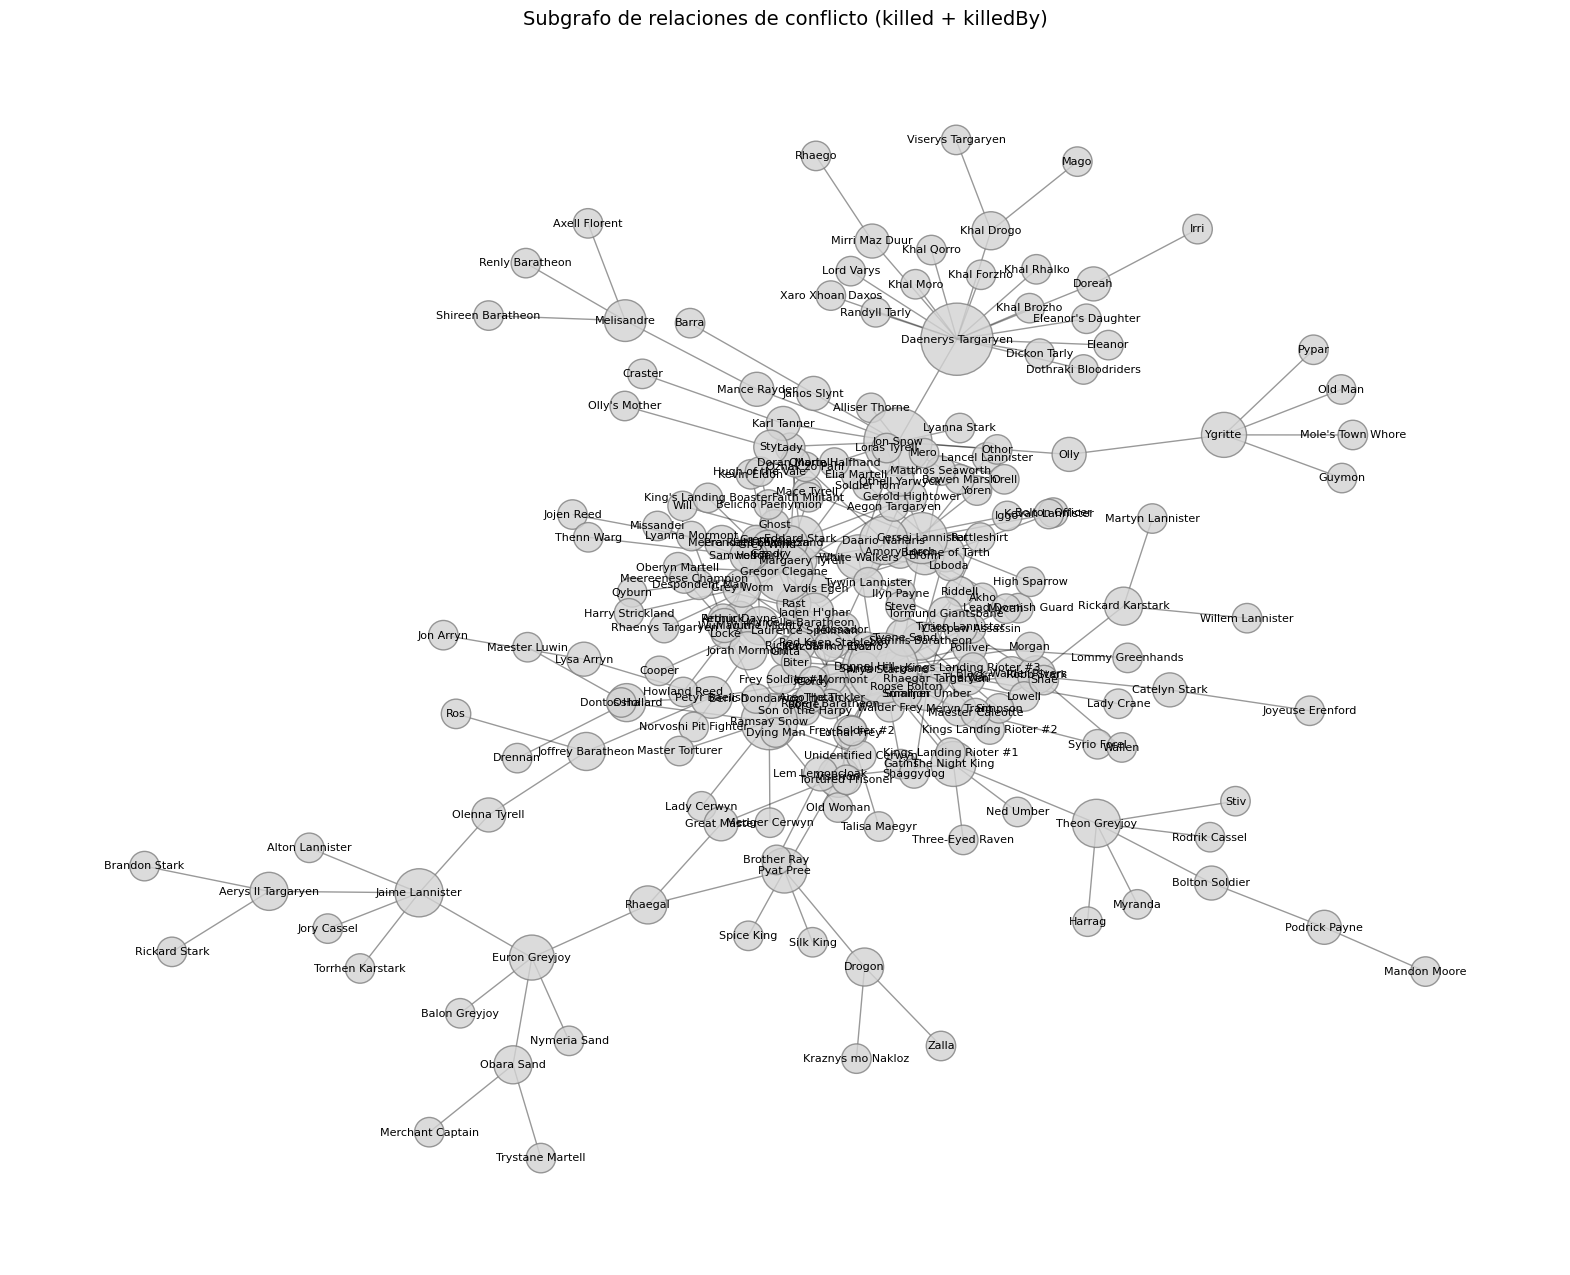

In [ ]:
# Subgrafo de relaciones familiares (siblings y parents)
relaciones_conflicto = {"killed", "killedBy"}

# Creamos el subgrafo filtrando las aristas del grafo original
edges_conflicto = [(u, v, d) for u, v, d in G.edges(data=True) if d['relation'] in relaciones_conflicto]
G_conflicto = nx.Graph()  # grafo no dirigido para relaciones de conflicto
G_conflicto.add_edges_from(edges_conflicto)

print(f"Número de nodos en el subgrafo de conflicto: {G_conflicto.number_of_nodes()}")
print(f"Número de aristas en el subgrafo de conflicto: {G_conflicto.number_of_edges()}")

# --- VISUALIZACIÓN DEL SUBGRAFO ---
plt.figure(figsize=(20, 16))
pos_conflicto = nx.kamada_kawai_layout(G_conflicto, scale= 500)

# Tamaño de nodos proporcional a su grado (más conexiones = más grande)
node_sizes = [300 + 150 * G_conflicto.degree(n) for n in G_conflicto.nodes()]

nx.draw_networkx_nodes(G_conflicto, pos_conflicto, node_size=node_sizes, node_color="lightgrey", alpha=0.8, edgecolors="gray")
nx.draw_networkx_edges(G_conflicto, pos_conflicto, alpha=0.4)
nx.draw_networkx_labels(G_conflicto, pos_conflicto, font_size=8)

plt.title("Subgrafo de relaciones de conflicto (killed + killedBy)", fontsize=14)
plt.axis("off")
plt.show()


**2. Aplica un algoritmo de detección de comunidades de las que ofrece la librería NetworkX para identificar grupos dentro de la red.**

In [112]:
from networkx.algorithms.community import greedy_modularity_communities

# Aplicamos el algoritmo de detección de comunidades
comunidades_conflicto = list(greedy_modularity_communities(G_conflicto))

# Asignamos un número de comunidad a cada nodo
comunidad_dict = {}
for i, comunidad in enumerate(comunidades_conflicto):
    for nodo in comunidad:
        comunidad_dict[nodo] = i

# Guardamos el número de comunidad como atributo del grafo
nx.set_node_attributes(G_conflicto, comunidad_dict, "comunidad")

**3. Realiza una visualización en la que cada comunidad aparezca con un color diferente.** 


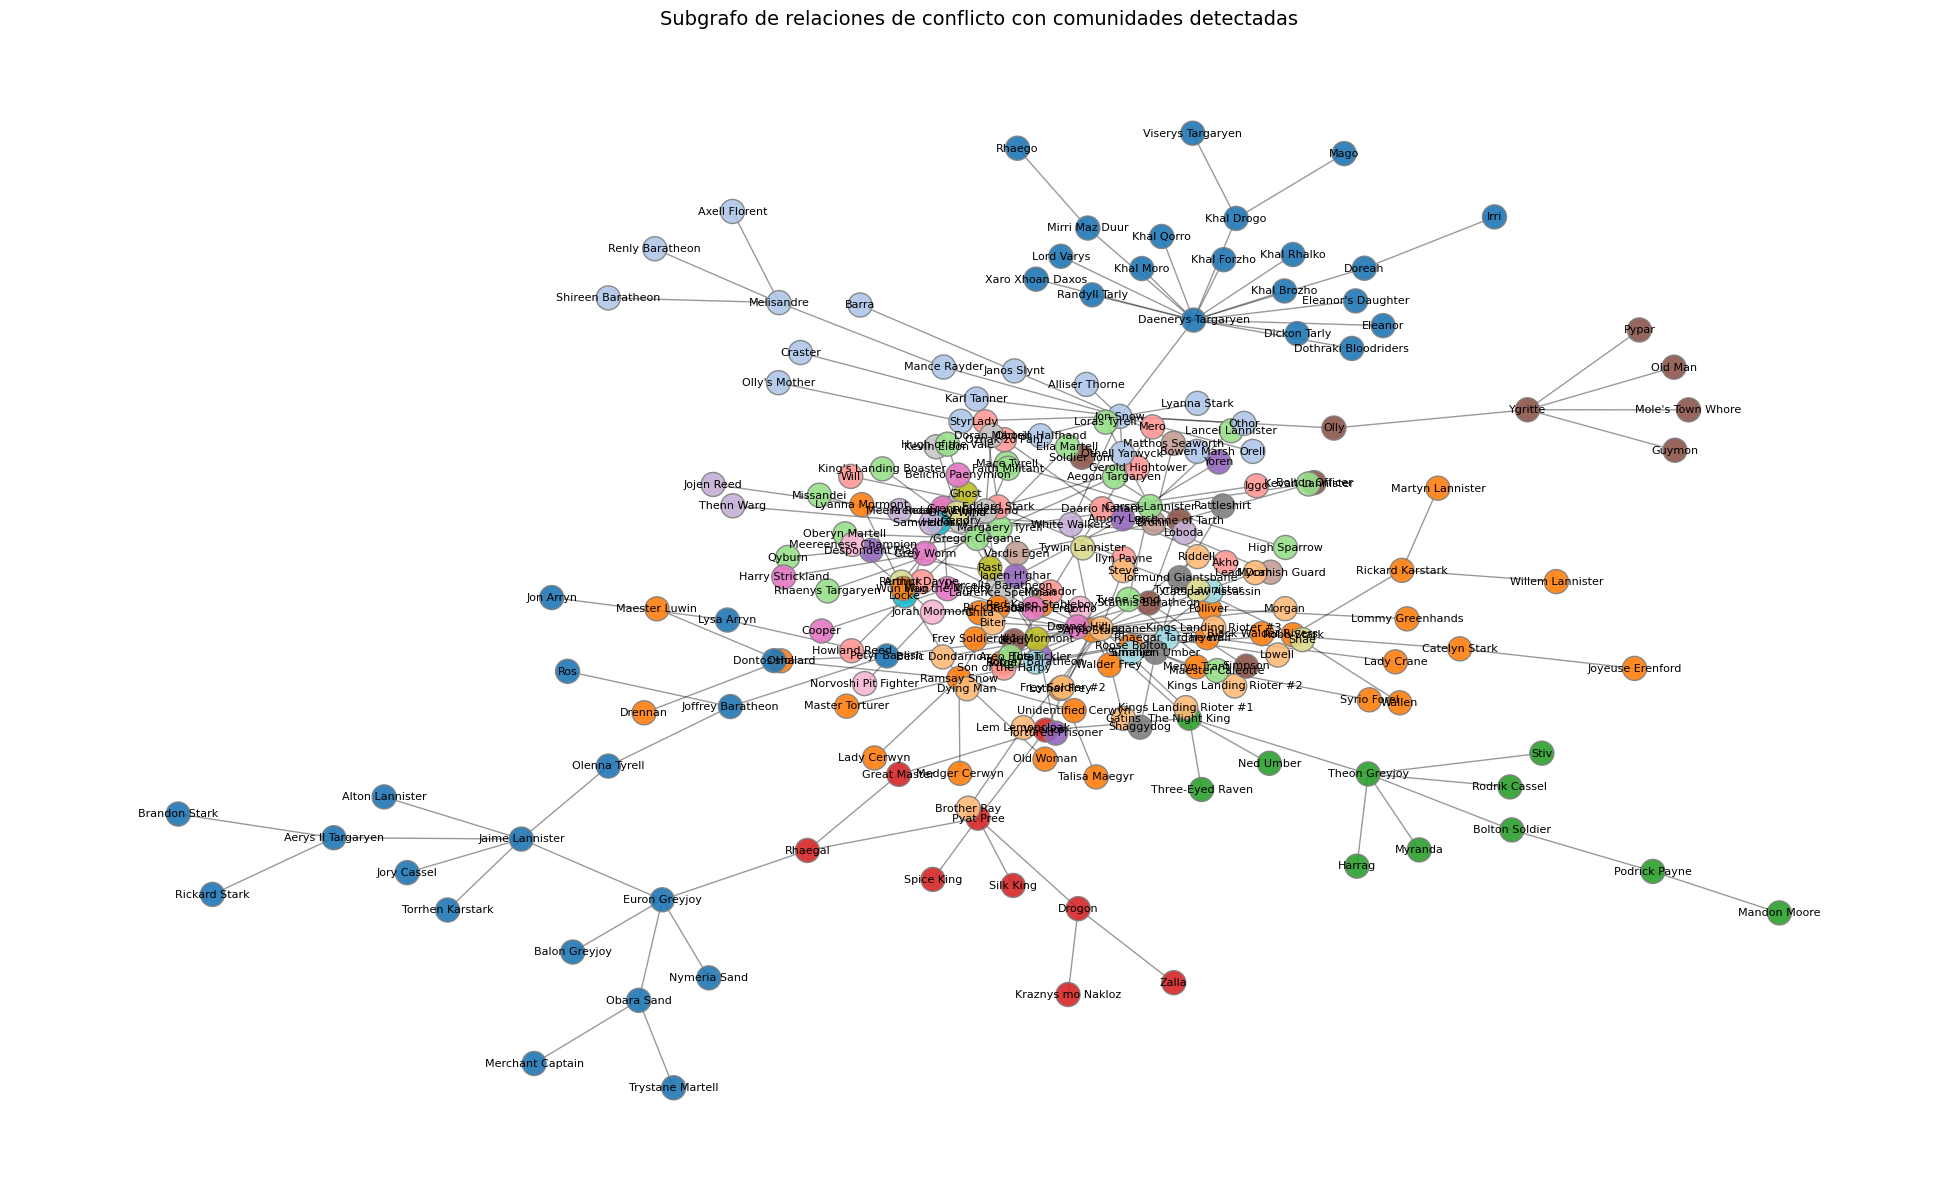

In [128]:
# --- VISUALIZACIÓN DEL SUBGRAFO CON COMUNIDADES ---
plt.figure(figsize=(25, 15))
pos_conflicto = nx.kamada_kawai_layout(G_conflicto, scale= 500,)
num_comunidades = len(comunidades_conflicto)
colormap = plt.cm.get_cmap("tab20", num_comunidades)
node_colors = [colormap(comunidad_dict.get(n, 0)) for n in G_conflicto.nodes()]
nx.draw_networkx_nodes(G_conflicto, pos_conflicto, node_color=node_colors, alpha=0.9, edgecolors="gray")
nx.draw_networkx_edges(G_conflicto, pos_conflicto, alpha=0.4)
nx.draw_networkx_labels(G_conflicto, pos_conflicto, font_size=8)
plt.title("Subgrafo de relaciones de conflicto con comunidades detectadas", fontsize=14)
plt.axis("off")
plt.show()

**4. Ajusta el tamaño de los nodos según su número de relaciones dentro de la comunidad seleccionada.**


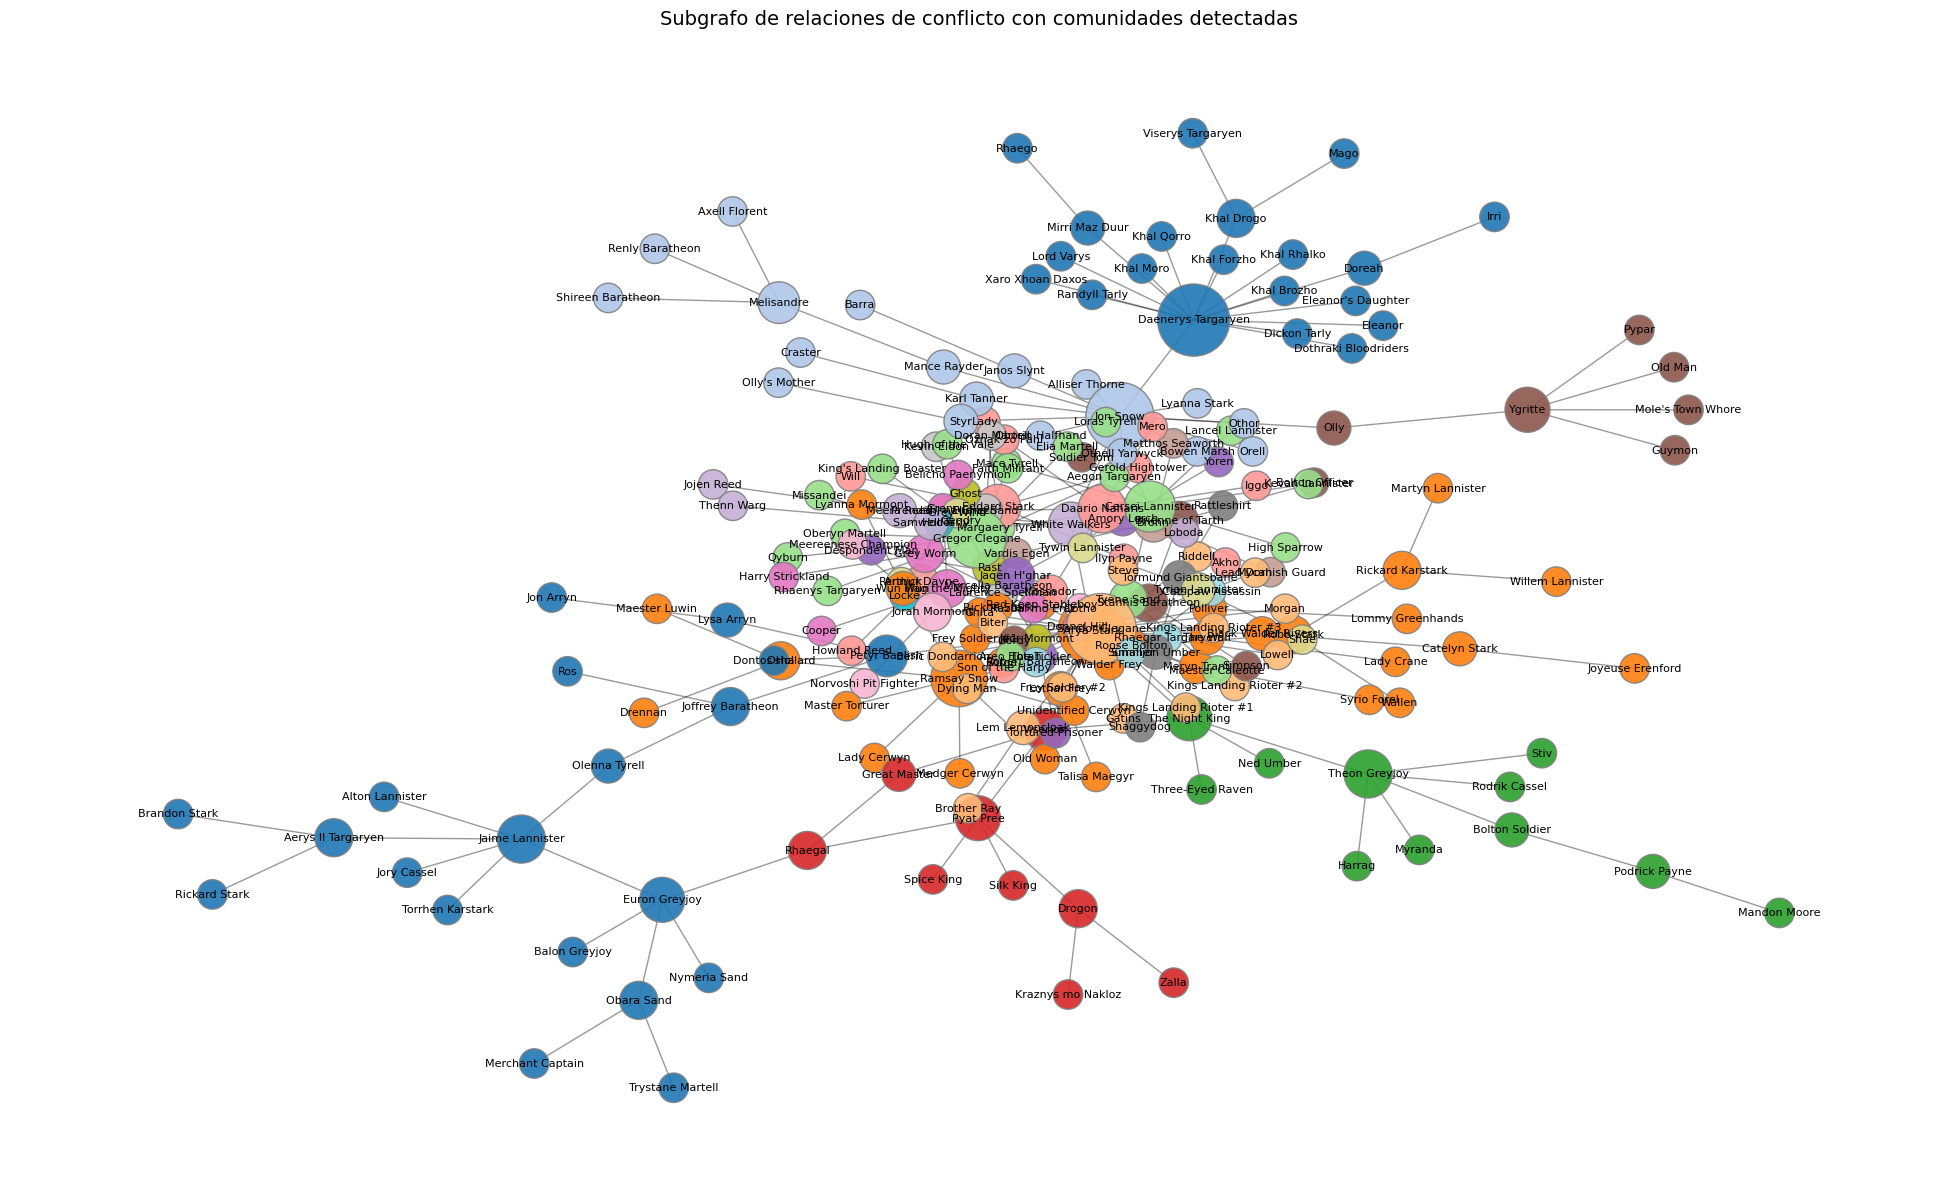

In [127]:
# --- VISUALIZACIÓN DEL SUBGRAFO CON COMUNIDADES ---
plt.figure(figsize=(25, 15))
pos_conflicto = nx.kamada_kawai_layout(G_conflicto, scale= 500,)
# Tamaño de nodos proporcional a su grado (más conexiones = más grande)
node_sizes = [300 + 150 * G_conflicto.degree(n) for n in G_conflicto.nodes()]
num_comunidades = len(comunidades_conflicto)
# Colores por comunidad
colormap = plt.cm.get_cmap("tab20", num_comunidades)
node_colors = [colormap(comunidad_dict.get(n, 0)) for n in G_conflicto.nodes()]
nx.draw_networkx_nodes(G_conflicto, pos_conflicto, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors="gray")
nx.draw_networkx_edges(G_conflicto, pos_conflicto, alpha=0.4)
nx.draw_networkx_labels(G_conflicto, pos_conflicto, font_size=8)
plt.title("Subgrafo de relaciones de conflicto con comunidades detectadas", fontsize=14)
plt.axis("off")
plt.show()

**Después de realizar el gráfico, responde brevemente:** 

**• ¿Cuántas comunidades principales has identificado?** 


**• ¿Coinciden estas comunidades con las casas nobles, alianzas o algún patrón que se pueda reconocer en la serie?** 

**• ¿Qué decisiones de diseño (colores, tamaño, layout) te han ayudado a mejorar la 
legibilidad del grafo?**